In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/subiecte_olimpiada_martie_2025_rev2.xlsx', on_bad_lines = 'skip')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb5 in position 10: invalid start byte

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Try specifying the encoding explicitly when reading the file.
# Common encodings for Windows files are 'cp1252', 'latin-1', or 'iso-8859-1'.
df = pd.read_csv('/content/subiecte_olimpiada_martie_2025_rev2.xlsx', on_bad_lines = 'skip', encoding='cp1252')
# or 'latin-1' or 'iso-8859-1'

UnicodeDecodeError: 'charmap' codec can't decode byte 0x8d in position 82: character maps to <undefined>

In [8]:
df = pd.read_csv('/content/subiecte_olimpiada_martie_2025_rev2.csv') # or 'cp1252' or other Windows code pages

In [9]:
df

,SEX,SCIV,VARSTA,MAINSTAT,HATLEVEL 1,HATFIELDNIV1,HATYEAR,NFEWORKSHOP,NFECOURSE,NFEGUIDEDJT,NFELESSON,NFEPLACE1,NFEPROVIDER1,NFEACT01_MAINSTAT,LANGMOTH1,LANGMOTH2,LANGUSED,LANGUSED_1
0,1,1,46,10,700,5,2011,1,2,2,2,1,4,1,RUM,000,1,ENG
1,1,1,24,10,354,7,2017,2,1,1,2,4,4,1,RUM,ENG,1,FRE
2,2,2,55,10,354,4,1985,2,2,1,2,4,4,1,RUM,000,0,000
3,1,1,53,10,353,7,2000,2,1,1,2,3,4,1,RUM,000,1,ITA
4,1,2,28,10,600,4,2018,2,1,2,2,4,8,1,RUM,000,1,ENG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2,2,32,10,600,2,2012,2,2,1,2,4,4,1,RUM,000,2,ENG
3496,2,1,39,10,700,3,2006,2,1,2,2,4,1,1,RUM,000,2,ENG
3497,2,1,39,10,700,3,2005,2,1,2,2,2,11,1,RUM,000,1,ENG
3498,2,1,26,10,344,0,2015,2,2,1,2,4,4,1,RUM,000,1,ENG


In [10]:
feature_columns = df.columns.tolist()
feature_columns

['SEX',
 'SCIV',
 'VARSTA',
 'MAINSTAT',
 'HATLEVEL 1',
 'HATFIELDNIV1',
 'HATYEAR',
 'NFEWORKSHOP',
 'NFECOURSE',
 'NFEGUIDEDJT',
 'NFELESSON',
 'NFEPLACE1',
 'NFEPROVIDER1',
 'NFEACT01_MAINSTAT',
 'LANGMOTH1',
 'LANGMOTH2',
 'LANGUSED',
 'LANGUSED_1']

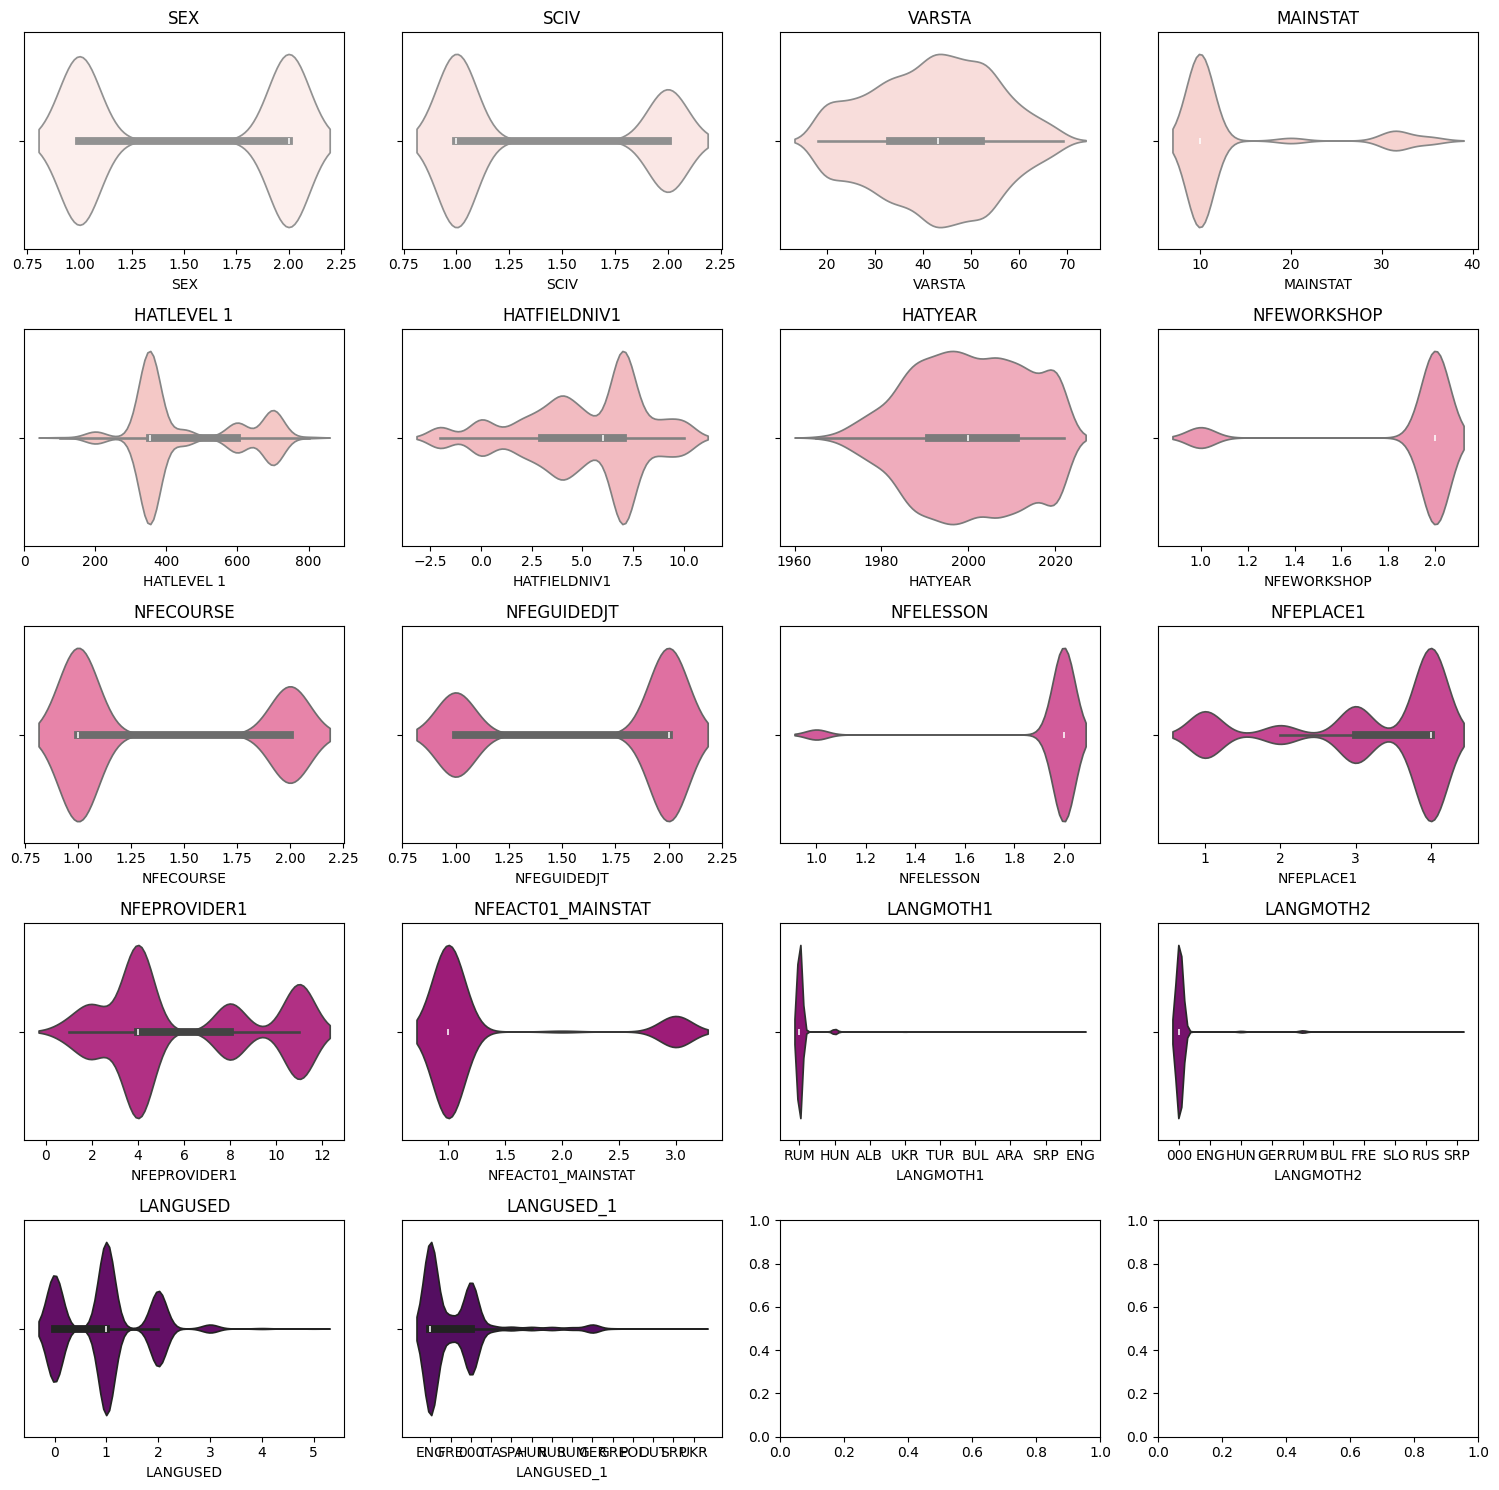

In [13]:
import numpy as np

#violin plot

num_features = len(feature_columns)
num_cols = 4
num_rows = int(np.ceil(num_features / num_cols))

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, num_rows * 3))

pink_palette = sns.color_palette("RdPu", n_colors=num_features)

for i, column in enumerate(feature_columns):
    row_idx = i // num_cols
    col_idx = i % num_cols
    sns.violinplot(x=df[column], ax=axes[row_idx, col_idx], color=pink_palette[i])
    axes[row_idx, col_idx].set_title(column)

plt.tight_layout()
plt.show()

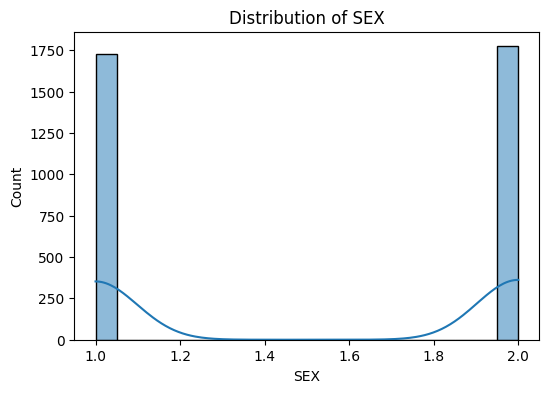

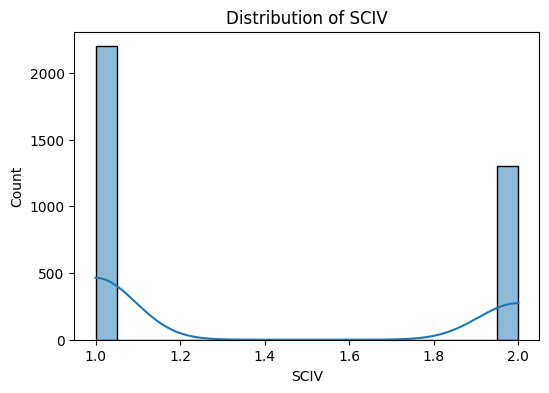

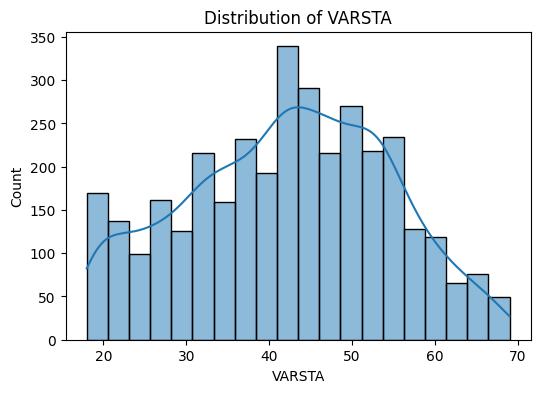

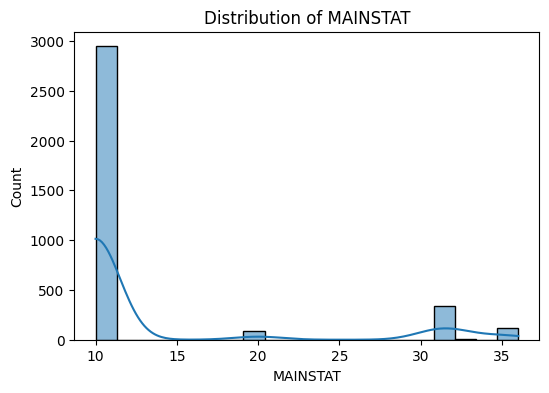

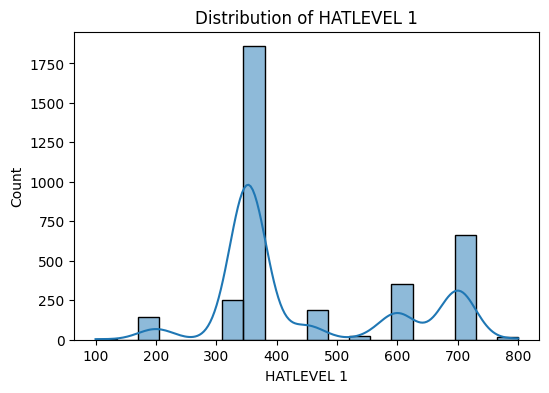

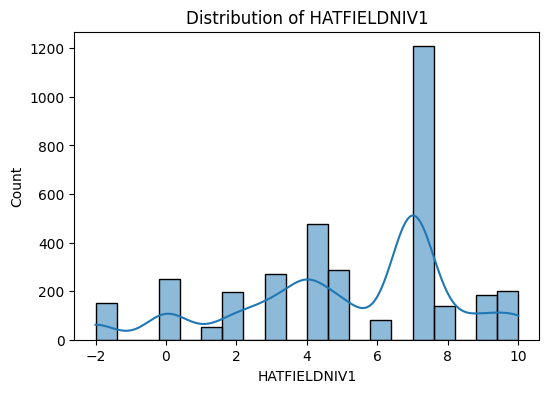

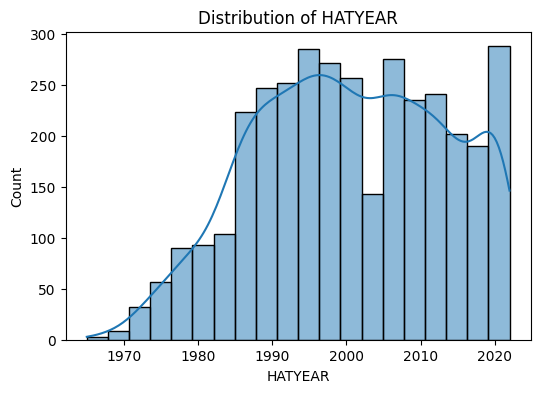

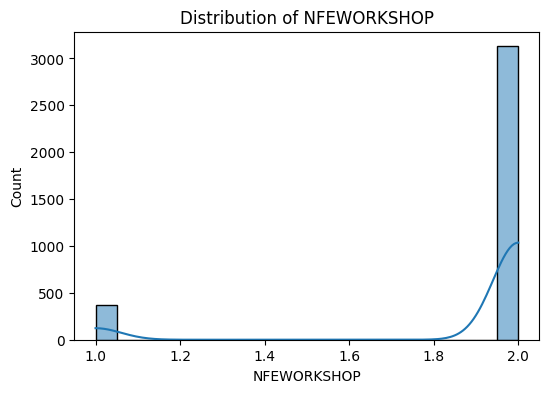

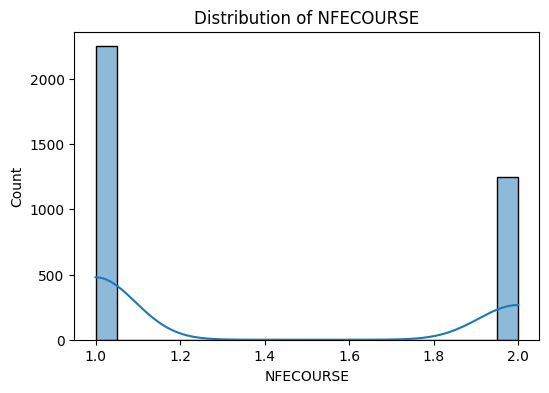

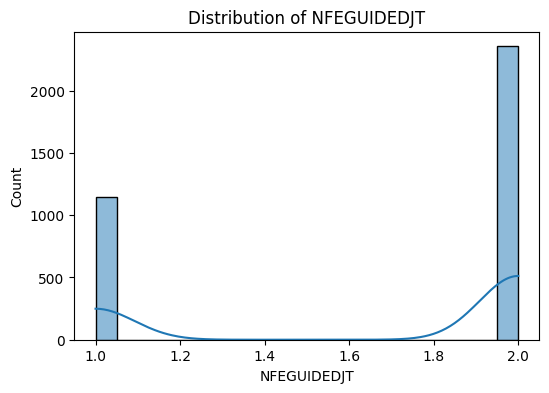

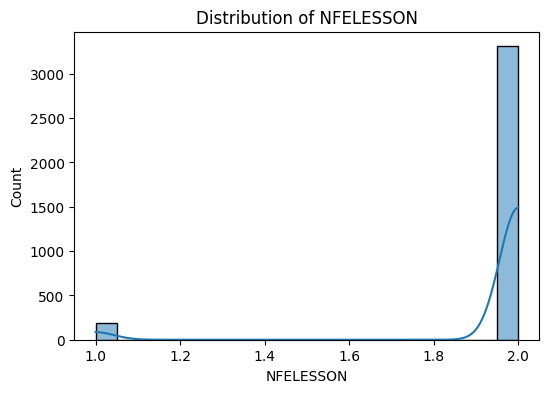

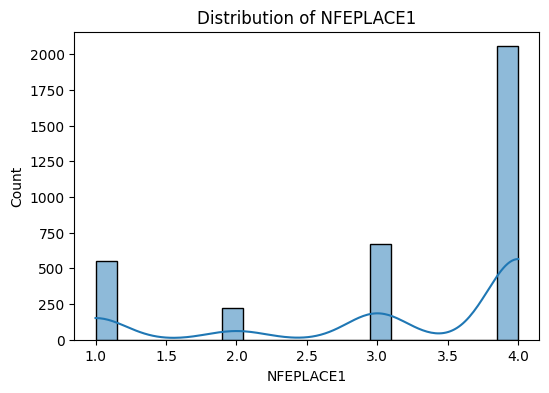

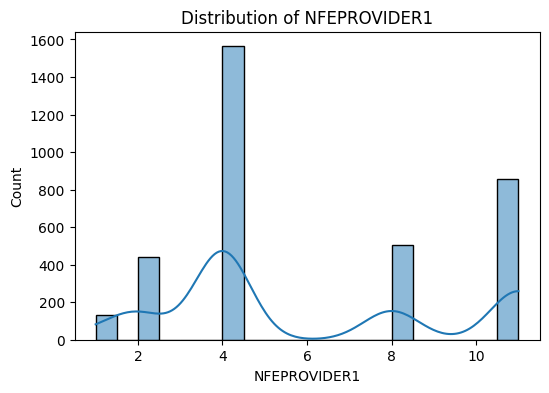

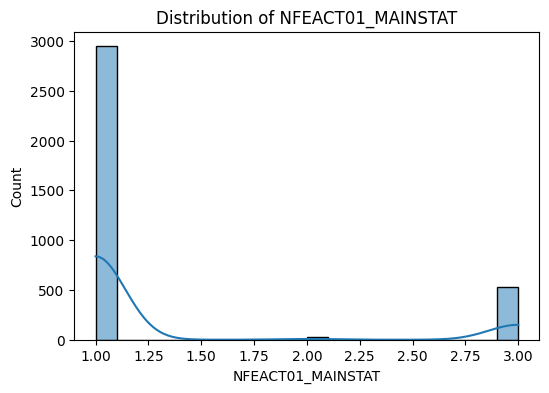

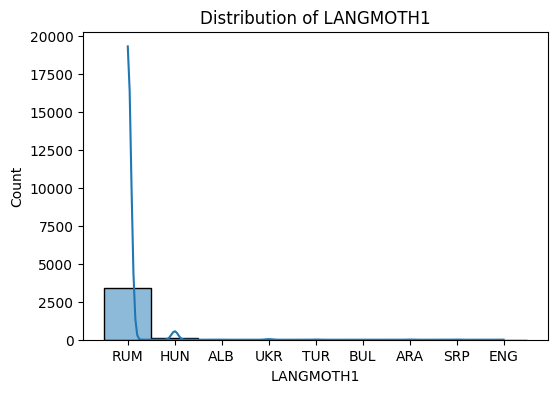

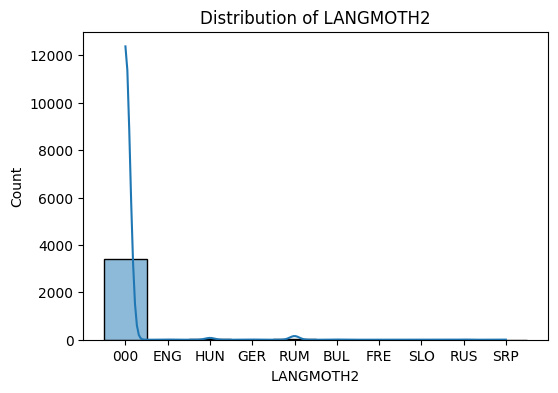

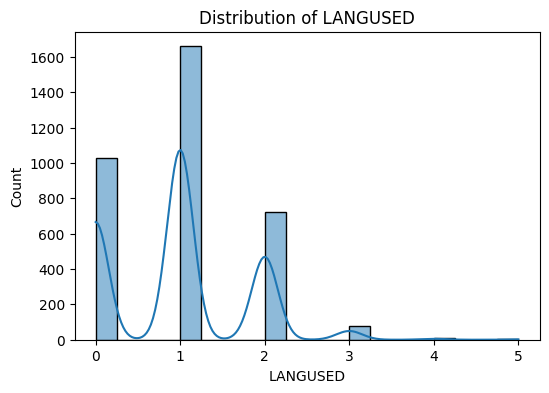

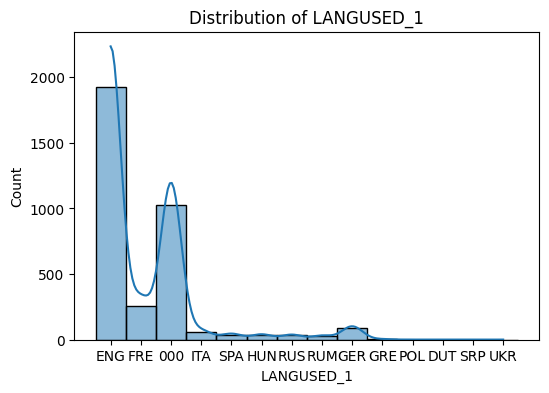

In [14]:
#histograma
for col in feature_columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    sns.histplot(df[col], kde=True, bins=20)  # Histogram with density curve
    plt.title(f'Distribution of {col}')  # Title
    plt.xlabel(col)  # X-axis label
    plt.ylabel('Count')  # Y-axis label
    plt.show()  # Show plot

In [15]:
stats = {}
for col in feature_columns:
    stats[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode().values.tolist(),  # Mode can be multiple values
        'Standard Deviation': df[col].std(),
        'Mean Absolute Deviation': df[col].mad(),
        'Variance': df[col].var()
    }

# Convert to DataFrame for better readability
stats_df = pd.DataFrame(stats).T
print(stats_df)


AttributeError: 'Series' object has no attribute 'mad'

In [16]:
stats = {}
for col in feature_columns:
    stats[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode().values.tolist(),  # Mode can be multiple values
        'Standard Deviation': df[col].std(),
        'Mean Absolute Deviation': pd.Series.mad(df[col]),  # Use pandas.Series.mad()
        'Variance': df[col].var()
    }

# Convert to DataFrame for better readability
stats_df = pd.DataFrame(stats).T
print(stats_df)

AttributeError: type object 'Series' has no attribute 'mad'

In [19]:
df_cleaned = df[~df.applymap(lambda x: isinstance(x, str)).any(axis=1)]

<ipython-input-19-c98de09b550e>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df[~df.applymap(lambda x: isinstance(x, str)).any(axis=1)]


In [27]:
for col in feature_columns:
  print(f'Mean for column {col}:', end = '')
  print(df[col].mean())

Mean for column SEX:1.5065714285714287
Mean for column SCIV:1.3717142857142857
Mean for column VARSTA:42.178285714285714
Mean for column MAINSTAT:13.241142857142858
Mean for column HATLEVEL 1:444.9502857142857
Mean for column HATFIELDNIV1:5.151714285714286
Mean for column HATYEAR:2000.5651428571427
Mean for column NFEWORKSHOP:1.8937142857142857
Mean for column NFECOURSE:1.3574285714285714
Mean for column NFEGUIDEDJT:1.6728571428571428
Mean for column NFELESSON:1.9457142857142857
Mean for column NFEPLACE1:3.2085714285714286
Mean for column NFEPROVIDER1:5.9311428571428575
Mean for column NFEACT01_MAINSTAT:1.3094285714285714
Mean for column LANGMOTH1:

TypeError: Could not convert string 'RUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMHUNRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMHUNRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUMRUM

In [30]:
for col in feature_columns:
  print(f'Median for column {col}:', end = '')
  print(df[col].median())

Median for column SEX:2.0
Median for column SCIV:1.0
Median for column VARSTA:43.0
Median for column MAINSTAT:10.0
Median for column HATLEVEL 1:354.0
Median for column HATFIELDNIV1:6.0
Median for column HATYEAR:2000.0
Median for column NFEWORKSHOP:2.0
Median for column NFECOURSE:1.0
Median for column NFEGUIDEDJT:2.0
Median for column NFELESSON:2.0
Median for column NFEPLACE1:4.0
Median for column NFEPROVIDER1:4.0
Median for column NFEACT01_MAINSTAT:1.0
Median for column LANGMOTH1:

TypeError: Cannot convert ['RUM' 'RUM' 'RUM' ... 'RUM' 'RUM' 'RUM'] to numeric

In [31]:
feature_columns

['SEX',
 'SCIV',
 'VARSTA',
 'MAINSTAT',
 'HATLEVEL 1',
 'HATFIELDNIV1',
 'HATYEAR',
 'NFEWORKSHOP',
 'NFECOURSE',
 'NFEGUIDEDJT',
 'NFELESSON',
 'NFEPLACE1',
 'NFEPROVIDER1',
 'NFEACT01_MAINSTAT',
 'LANGMOTH1',
 'LANGMOTH2',
 'LANGUSED',
 'LANGUSED_1']

In [32]:
feature_columns = ['SEX',
 'SCIV',
 'VARSTA',
 'MAINSTAT',
 'HATLEVEL 1',
 'HATFIELDNIV1',
 'HATYEAR',
 'NFEWORKSHOP',
 'NFECOURSE',
 'NFEGUIDEDJT',
 'NFELESSON',
 'NFEPLACE1',
 'NFEPROVIDER1',
 'NFEACT01_MAINSTAT', 'LANGMOTH2',
 'LANGUSED',
 'LANGUSED_1']

In [34]:
df_cleaned = df[~df.applymap(lambda x: isinstance(x, str)).any(axis=1)]
feature_columns = df_cleaned.columns.tolist()

<ipython-input-34-59b7dcc89865>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df[~df.applymap(lambda x: isinstance(x, str)).any(axis=1)]


In [35]:
feature_columns

['SEX',
 'SCIV',
 'VARSTA',
 'MAINSTAT',
 'HATLEVEL 1',
 'HATFIELDNIV1',
 'HATYEAR',
 'NFEWORKSHOP',
 'NFECOURSE',
 'NFEGUIDEDJT',
 'NFELESSON',
 'NFEPLACE1',
 'NFEPROVIDER1',
 'NFEACT01_MAINSTAT',
 'LANGMOTH1',
 'LANGMOTH2',
 'LANGUSED',
 'LANGUSED_1']

In [41]:
plt.figure(figsize = (20, 8))
sns.heatmap(df_cleaned[feature_columns].corr(), annot = True, cmap = 'coolwarm')
plt.show()

ValueError: could not convert string to float: 'RUM'

<Figure size 2000x800 with 0 Axes>

In [39]:
type(df['SEX'][1])

numpy.int64

In [40]:
numeric_columns = ['SCIV', 'VARSTA', 'HATLEVEL 1', 'HATFIELDNIV1',
                   'HATYEAR', 'NFEWORKSHOP', 'NFECOURSE', 'NFEGUIDEDJT',
                   'NFELESSON', 'NFEPLACE1', 'NFEPROVIDER1', 'NFEACT01_MAINSTAT',
                   'LANGMOTH2', 'LANGUSED', 'LANGUSED_1']

# 2. Convert to Numeric
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # 'coerce' converts non-numeric to NaN

# 3. Filter NaN Rows
df_cleaned = df.dropna(subset=numeric_columns)  # Drop rows with NaN in numeric columns

<ipython-input-42-4fbf384fa217>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')  # 'coerce' converts non-numeric to NaN


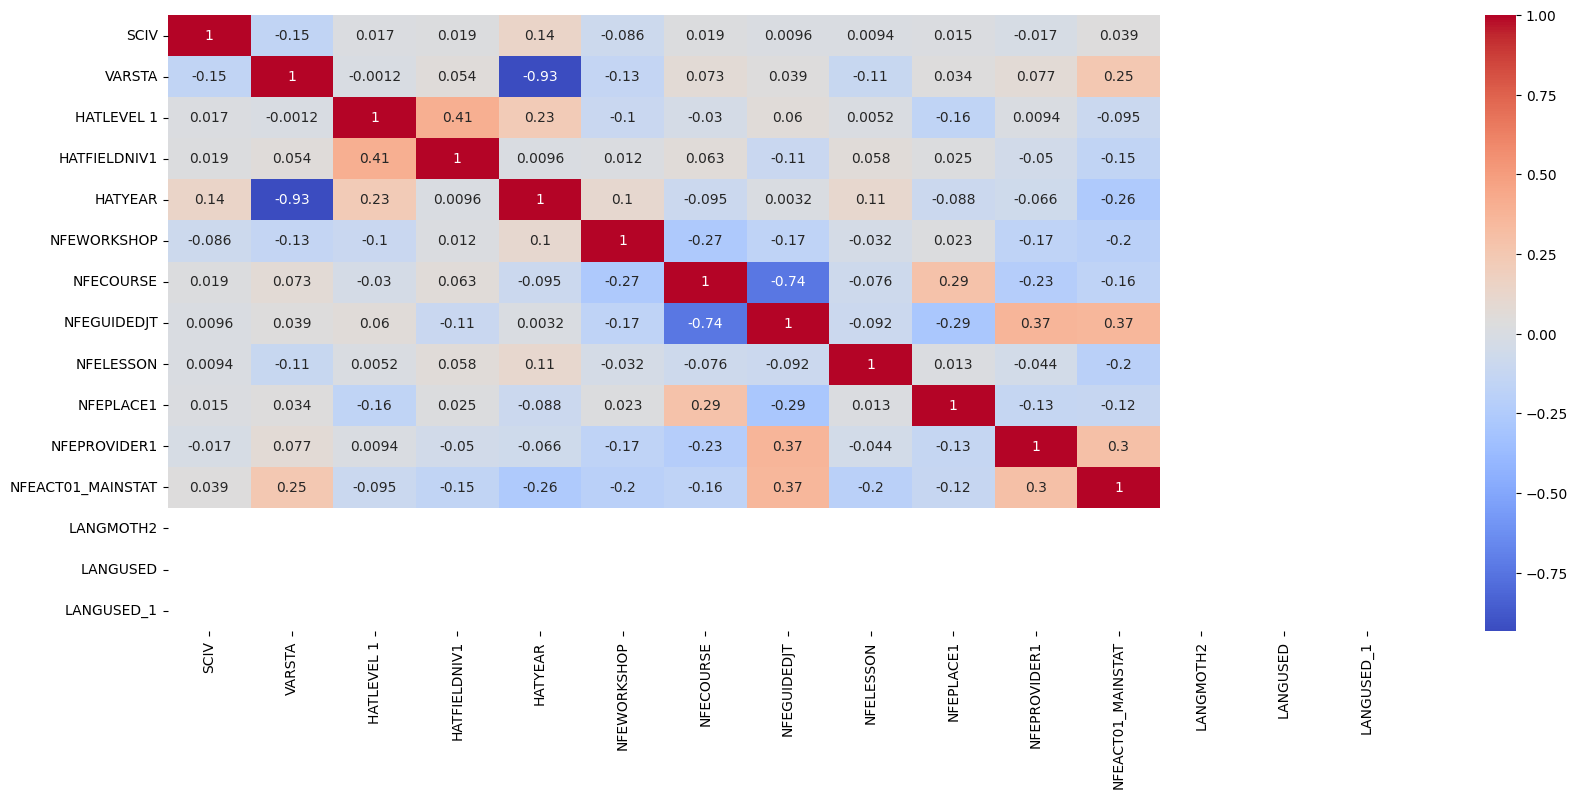

In [42]:
numeric_columns = ['SCIV', 'VARSTA', 'HATLEVEL 1', 'HATFIELDNIV1',
                   'HATYEAR', 'NFEWORKSHOP', 'NFECOURSE', 'NFEGUIDEDJT',
                   'NFELESSON', 'NFEPLACE1', 'NFEPROVIDER1', 'NFEACT01_MAINSTAT',
                   'LANGMOTH2', 'LANGUSED', 'LANGUSED_1']
categorical_columns = ['SEX', 'MAINSTAT'] # Assuming these are your categorical columns

# 2. Convert Numeric Columns to Numeric
for col in numeric_columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')  # 'coerce' converts non-numeric to NaN

# 3. Filter NaN Rows in Numeric Columns
df_cleaned = df_cleaned.dropna(subset=numeric_columns)  # Drop rows with NaN in numeric columns

# 4. Calculate Correlation for Numeric Columns Only
plt.figure(figsize = (20, 8))
sns.heatmap(df_cleaned[numeric_columns].corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [46]:
print(df.isnull().value_counts())

SEX    SCIV   VARSTA  MAINSTAT  HATLEVEL 1  HATFIELDNIV1  HATYEAR  NFEWORKSHOP  NFECOURSE  NFEGUIDEDJT  NFELESSON  NFEPLACE1  NFEPROVIDER1  NFEACT01_MAINSTAT  LANGMOTH1  LANGMOTH2  LANGUSED  LANGUSED_1
False  False  False   False     False       False         False    False        False      False        False      False      False         False              False      False      False     True          2416
                                                                                                                                                                                               False         1009
                                                                                                                                                                          True       False     True            55
                                                                                                                                                                        

In [50]:
df['SEX'].value_counts() # sa rulati aceasta comanda pentru fiecare coloana

,count
SEX,
2,1773
1,1727


In [51]:
df.duplicated().sum()

62

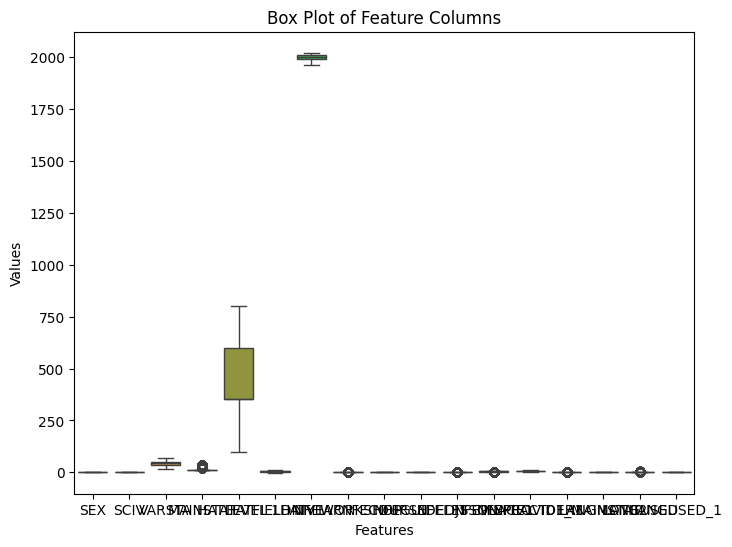

In [52]:

#Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[feature_columns])
plt.title("Box Plot of Feature Columns")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

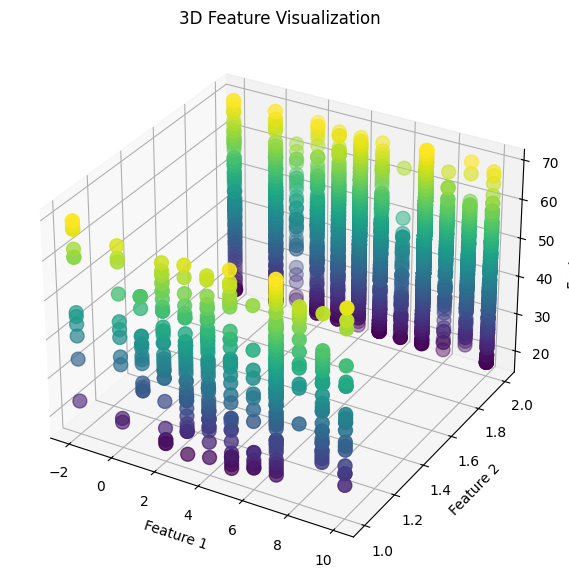

In [55]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['HATFIELDNIV1'], df['NFEWORKSHOP'], df['VARSTA'], c=df['VARSTA'], cmap='viridis', s=100)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D Feature Visualization')

plt.show()